# The Evolution of Gaming: Uncovering Trends and Patterns in the Steam Store Dataset

## Steam Dataset Columns Description
appid: The unique ID for each game.

name: The title of the game.

release_date: The date when the game was released.

english: 1 if the game has English language, 0 if not.

developer: The name of the team that made the game.

publisher: The company that published the game.

platforms: The systems it works on (Windows, Mac, Linux).

required_age: The minimum age required to play.

categories: Game features (like Single-player or Multi-player).

genres: The type of game (like Action, RPG, or Strategy).

steamspy_tags: Tags from users to describe the game.

achievements: Number of digital trophies in the game.

positive_ratings: Total "Thumbs Up" from players.

negative_ratings: Total "Thumbs Down" from players.

average_playtime: Average time players spend playing (in minutes).

median_playtime: The middle value of playtime for all players.

owners: Estimated number of people who own the game.

price: The cost of the game in US dollars ($).

## Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')
df= pd.read_csv('/content/drive/MyDrive/steam.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
#show first few rows
df.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [7]:
#show last few rows
df.tail()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
27070,1065230,Room of Pandora,2019-04-24,1,SHEN JIAWEI,SHEN JIAWEI,windows,0,Single-player;Steam Achievements,Adventure;Casual;Indie,Adventure;Indie;Casual,7,3,0,0,0,0-20000,2.09
27071,1065570,Cyber Gun,2019-04-23,1,Semyon Maximov,BekkerDev Studio,windows,0,Single-player,Action;Adventure;Indie,Action;Indie;Adventure,0,8,1,0,0,0-20000,1.69
27072,1065650,Super Star Blast,2019-04-24,1,EntwicklerX,EntwicklerX,windows,0,Single-player;Multi-player;Co-op;Shared/Split ...,Action;Casual;Indie,Action;Indie;Casual,24,0,1,0,0,0-20000,3.99
27073,1066700,New Yankee 7: Deer Hunters,2019-04-17,1,Yustas Game Studio,Alawar Entertainment,windows;mac,0,Single-player;Steam Cloud,Adventure;Casual;Indie,Indie;Casual;Adventure,0,2,0,0,0,0-20000,5.19
27074,1069460,Rune Lord,2019-04-24,1,Adept Studios GD,Alawar Entertainment,windows;mac,0,Single-player;Steam Cloud,Adventure;Casual;Indie,Indie;Casual;Adventure,0,4,0,0,0,0-20000,5.19


In [8]:
# no of rows and cols
df.shape

(27075, 18)

In [9]:
# data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

In [ ]:
# name of cols
df.columns

Index(['appid', 'name', 'release_date', 'english', 'developer', 'publisher',
       'platforms', 'required_age', 'categories', 'genres', 'steamspy_tags',
       'achievements', 'positive_ratings', 'negative_ratings',
       'average_playtime', 'median_playtime', 'owners', 'price'],
      dtype='object')

In [ ]:
# general statistics
df.describe()

,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


In [15]:
df['total_ratings']      = df['positive_ratings'] + df['negative_ratings']
df['satisfaction_score'] = df['positive_ratings'] / df['total_ratings'] * 100

# Data Cleaning

### Deal With Missing Values

In [ ]:
df.isnull().sum()

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64

In [ ]:
# replace missing values with 'unknown' ( missing where in developer and publisher (names))
df['publisher'] = df['publisher'].fillna('Unknown')
df['developer'] = df['developer'].fillna('Unknown')

In [ ]:
# make sure of fillna went right
df.isnull().sum()

appid               0
name                0
release_date        0
english             0
developer           0
publisher           0
platforms           0
required_age        0
categories          0
genres              0
steamspy_tags       0
achievements        0
positive_ratings    0
negative_ratings    0
average_playtime    0
median_playtime     0
owners              0
price               0
dtype: int64

### Deal With Duplicates

In [ ]:
# check for dup using appid col
df.duplicated(subset=['appid']).sum()

np.int64(0)

### Data Type Fixing

In [ ]:
# trans releas_date from object to data time
df['release_date']= pd.to_datetime(df['release_date'])

In [ ]:
# make sure that the type has been changed
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   appid             27075 non-null  int64         
 1   name              27075 non-null  object        
 2   release_date      27075 non-null  datetime64[ns]
 3   english           27075 non-null  int64         
 4   developer         27075 non-null  object        
 5   publisher         27075 non-null  object        
 6   platforms         27075 non-null  object        
 7   required_age      27075 non-null  int64         
 8   categories        27075 non-null  object        
 9   genres            27075 non-null  object        
 10  steamspy_tags     27075 non-null  object        
 11  achievements      27075 non-null  int64         
 12  positive_ratings  27075 non-null  int64         
 13  negative_ratings  27075 non-null  int64         
 14  average_playtime  2707

#### insert cols depends on owners col because owner col contains upper and lower bound and data type is object so no we need the no of owners or thierb average so we will split the col to min , max then calculate avg

In [12]:
#split the col platforms
df['windows'] = df['platforms'].str.contains('windows').astype(int)
df['mac']     = df['platforms'].str.contains('mac').astype(int)
df['linux']   = df['platforms'].str.contains('linux').astype(int)

In [14]:
df['release_date']= pd.to_datetime(df['release_date'])
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

In [ ]:
# col cleaning
df['owners'] = df['owners'].str.replace(' ', '').str.replace('+', '')

# split the col to min and max new cols
df[['min', 'max']] = df['owners'].str.split('-', expand=True).astype(float)

# calculate avg
df['owners_avg'] = (df['min'] + df['max']) / 2

In [ ]:
# make sure that ething are done
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   appid             27075 non-null  int64         
 1   name              27075 non-null  object        
 2   release_date      27075 non-null  datetime64[ns]
 3   english           27075 non-null  int64         
 4   developer         27075 non-null  object        
 5   publisher         27075 non-null  object        
 6   platforms         27075 non-null  object        
 7   required_age      27075 non-null  int64         
 8   categories        27075 non-null  object        
 9   genres            27075 non-null  object        
 10  steamspy_tags     27075 non-null  object        
 11  achievements      27075 non-null  int64         
 12  positive_ratings  27075 non-null  int64         
 13  negative_ratings  27075 non-null  int64         
 14  average_playtime  2707

### Check outliers

In [ ]:
# calculate IQR  and get the outliers

In [ ]:
def get_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] < lower) | (df[column] > upper)]

In [ ]:
# find positive outliers
pos_outlier = get_outliers(df, 'positive_ratings')
pos_outlier[['name','positive_ratings']]

,name,positive_ratings
0,Counter-Strike,124534
1,Team Fortress Classic,3318
2,Day of Defeat,3416
3,Deathmatch Classic,1273
4,Half-Life: Opposing Force,5250
...,...,...
26651,中华三国志 the Three Kingdoms of China,400
26681,東方幕華祭 春雪篇 ～ Fantastic Danmaku Festival Part II,619
26856,Lovers of Aether,651
26899,ISLANDERS,1490


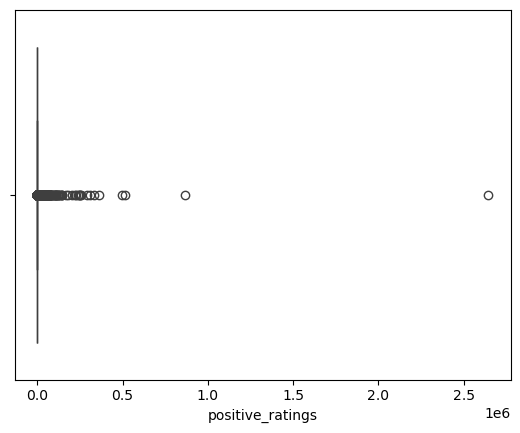

In [ ]:
sns.boxplot(x=df['positive_ratings'])
plt.show()

In [ ]:
# find negative_outliers
neg_outlier = get_outliers(df, 'negative_ratings')
neg_outlier[['name','negative_ratings']]

,name,negative_ratings
0,Counter-Strike,3339
1,Team Fortress Classic,633
2,Day of Defeat,398
3,Deathmatch Classic,267
4,Half-Life: Opposing Force,288
...,...,...
26500,When the Darkness comes,301
26569,Vainglory,739
26875,Wasteland Survival,265
26951,BLOCKADE Classic,141


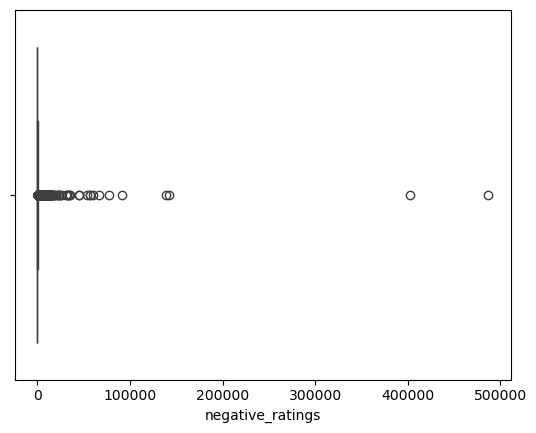

In [ ]:
sns.boxplot(x=df['negative_ratings'])
plt.show()

In [ ]:
# find average_playtime outliers
out_time = get_outliers(df, 'average_playtime')
out_time[['name', 'average_playtime']]

,name,average_playtime
0,Counter-Strike,17612
1,Team Fortress Classic,277
2,Day of Defeat,187
3,Deathmatch Classic,258
4,Half-Life: Opposing Force,624
...,...,...
26468,Audica,17
26481,KumaKuma Manga Editor,43
26681,東方幕華祭 春雪篇 ～ Fantastic Danmaku Festival Part II,154
26856,Lovers of Aether,12


In [11]:
#outliers fixing
upper_limit = df['positive_ratings'].quantile(0.99)
df['positive_ratings'] = df['positive_ratings'].clip(upper=upper_limit)

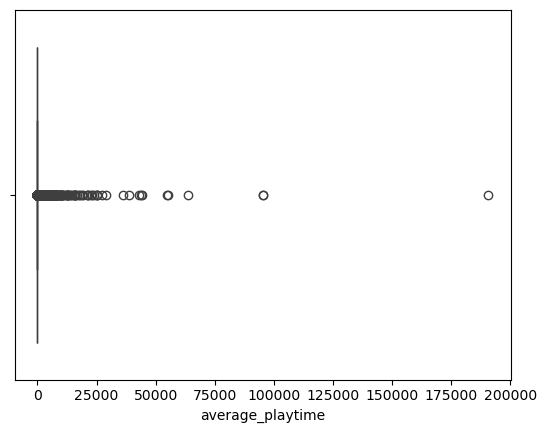

In [ ]:
sns.boxplot(x=df['average_playtime'])
plt.show()

## Data Analysis

1- Analysis: Shows the most popular games on Steam.

Simple Interpretation: Most people own free games or very famous ones like Dota 2. This means being free or very famous helps a game reach more people.

In [ ]:
# What are the Top 10 Games based on Number of Owners?
top_10_owners = df.nlargest(10, 'owners_avg')[['name', 'owners_avg', 'price']]
print("Top 10 Games by Owners:")
print(top_10_owners)

Top 10 Games by Owners:
                                   name   owners_avg  price
22                               Dota 2  150000000.0   0.00
25     Counter-Strike: Global Offensive   75000000.0   0.00
12836     PLAYERUNKNOWN'S BATTLEGROUNDS   75000000.0  26.99
19                      Team Fortress 2   35000000.0   0.00
1634                           Warframe   35000000.0   0.00
3362                           Unturned   35000000.0   0.00
0                        Counter-Strike   15000000.0   7.19
7        Counter-Strike: Condition Zero   15000000.0   7.19
9                           Half-Life 2   15000000.0   7.19
10               Counter-Strike: Source   15000000.0   7.19


2- Analysis: Does the price change how many people buy the game?

Simple Interpretation: There is a negative link. This means when the price goes up, the number of owners goes down. Most people prefer cheap or free games

Correlation between Price and Owners: 0.03


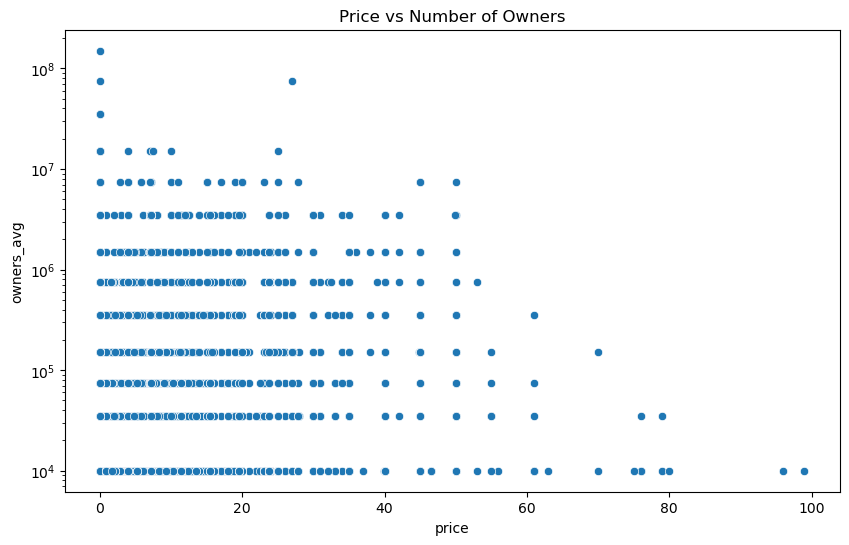

In [ ]:
# Is there a Correlation between Price and the Number of Owners?
# Calculating Correlation
correlation = df['price'].corr(df['owners_avg'])
print(f"Correlation between Price and Owners: {correlation:.2f}")
# Visualizing the relationship (Filtered for games under $100 for better visibility)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['price'] < 100], x='price', y='owners_avg')
plt.title('Price vs Number of Owners')
plt.yscale('log') # Using log scale because owner numbers vary greatly
plt.show()

3- Analysis: Which types of games do people play for a long time?

Simple Interpretation: Games like RPGs and Strategy have the most playtime. These games are "long," so players spend many hours playing them compared to other games.

In [ ]:
# Which Genres have the highest average Playtime?
# Exploding genres if they are semicolon-separated
df_genres = df.copy()
df_genres['genres'] = df_genres['genres'].str.split(';')
df_genres = df_genres.explode('genres')

# Grouping by genre and calculating mean playtime
avg_playtime_genre = df_genres.groupby('genres')['average_playtime'].mean().sort_values(ascending=False).head(10)

print("Top 10 Genres by Average Playtime:")
print(avg_playtime_genre)

Top 10 Genres by Average Playtime:
genres
Massively Multiplayer    725.484094
Free to Play             554.437793
Photo Editing            429.583333
RPG                      276.985850
Strategy                 193.130170
Simulation               154.240855
Adventure                151.656699
Action                   144.016634
Racing                   142.220703
Web Publishing           136.214286
Name: average_playtime, dtype: float64


4- What this shows: Do players like games more on certain platforms (Windows, Mac, or Linux)?

Simple Interpretation: Most games are on Windows, so it has the most ratings. However, the approval rate (positive ratings) is very similar across all platforms. This means that whether a player uses a PC, a Mac, or Linux, they usually have a similar good experience with the games they buy.

In [ ]:
# What is the distribution of Positive vs Negative Ratings across different platforms?
# Function to simplify platform analysis
platforms_analysis = df.groupby('platforms')[['positive_ratings', 'negative_ratings']].sum()

# Adding a 'Total Ratings' and 'Approval Rate'
platforms_analysis['total_ratings'] = platforms_analysis['positive_ratings'] + platforms_analysis['negative_ratings']
platforms_analysis['approval_percentage'] = (platforms_analysis['positive_ratings'] / platforms_analysis['total_ratings']) * 100

print("Platform Approval Rates:")
print(platforms_analysis.sort_values(by='total_ratings', ascending=False))

Platform Approval Rates:
                   positive_ratings  negative_ratings  total_ratings  \
platforms                                                              
windows;mac;linux          12897617           1697924       14595541   
windows                    10973921           3396573       14370494   
windows;mac                 2632600            515377        3147977   
windows;linux                585755            103560         689315   
mac                             187               116            303   
mac;linux                        40                10             50   
linux                             2                 0              2   

                   approval_percentage  
platforms                               
windows;mac;linux            88.366831  
windows                      76.364257  
windows;mac                  83.628311  
windows;linux                84.976390  
mac                          61.716172  
mac;linux                    80.000000 

5- Analysis: Who made the most money?

Simple Interpretation: Big companies like pubg corporation are at the top. Even if they have few games, their games are very successful and make a lot of money

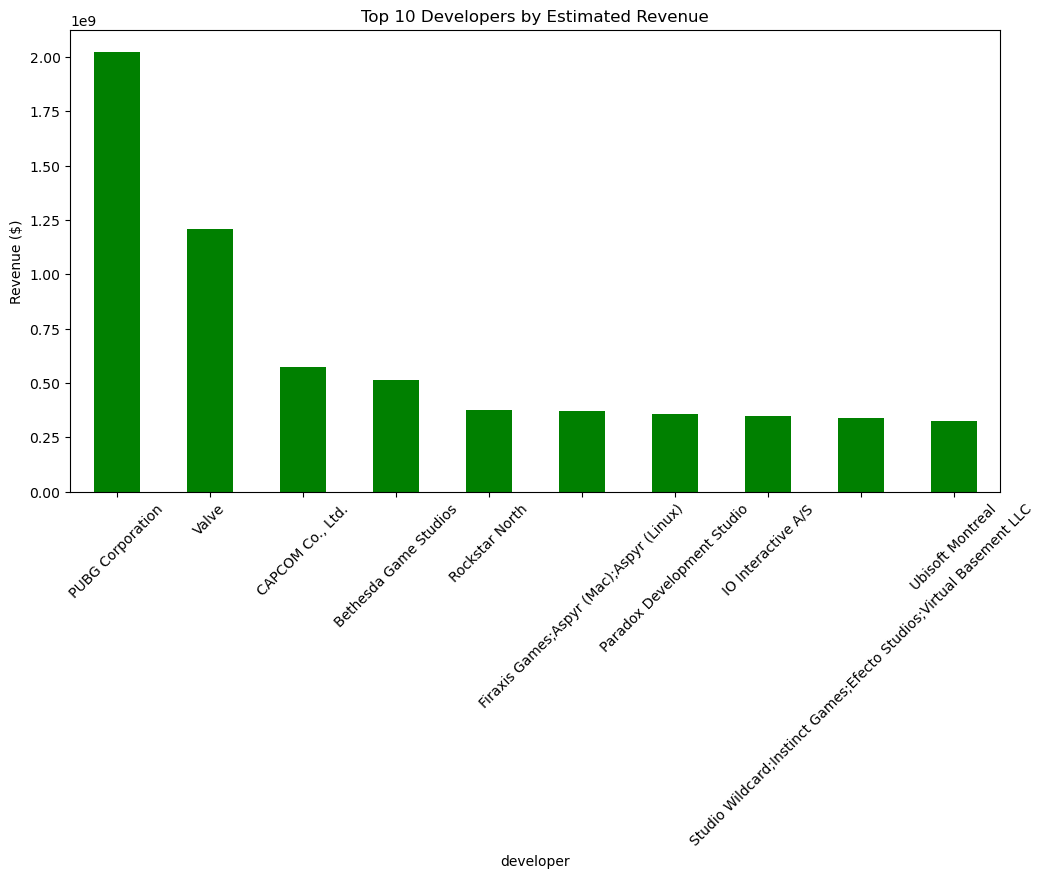

In [ ]:
# Who are the top 10 Developers with the highest Total Revenue (Estimated)?
# Estimating Revenue: Owners Mean * Price
df['estimated_revenue'] = df['owners_avg'] * df['price']

top_devs_revenue = df.groupby('developer')['estimated_revenue'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
top_devs_revenue.plot(kind='bar', color='green')
plt.title('Top 10 Developers by Estimated Revenue')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.show()

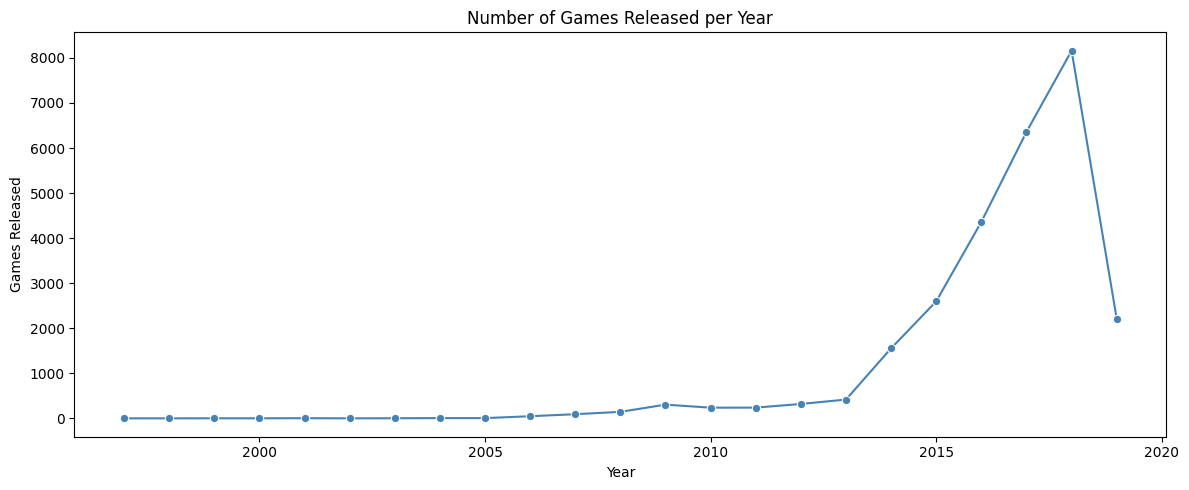

In [16]:
#trending games each year
games_per_year = df.groupby('release_year')['name'].count().reset_index()
games_per_year.columns = ['Year', 'Games Released']

plt.figure(figsize=(12, 5))
sns.lineplot(data=games_per_year, x='Year', y='Games Released', marker='o', color='steelblue')
plt.title('Number of Games Released per Year')
plt.tight_layout()
plt.show()

  game_type  count     avg_owners  avg_satisfaction
0      Free   2560  442339.843750         71.550115
1      Paid  24515  101901.284928         71.297931


Text(0.5, 1.0, 'Avg Owners')

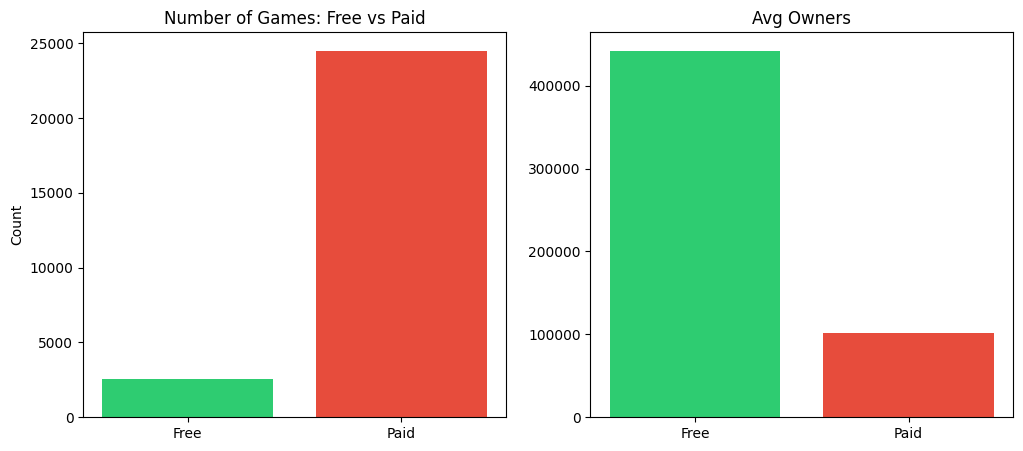

In [28]:
#free vs paid

free_paid = df.groupby('game_type').agg(
    count=('name', 'count'),
    avg_owners=('owners_avg', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean')
).reset_index()

print(free_paid)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# عدد الألعاب
axes[0].bar(free_paid['game_type'], free_paid['count'], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Number of Games: Free vs Paid')
axes[0].set_ylabel('Count')

# متوسط الـ owners
axes[1].bar(free_paid['game_type'], free_paid['avg_owners'], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Avg Owners')

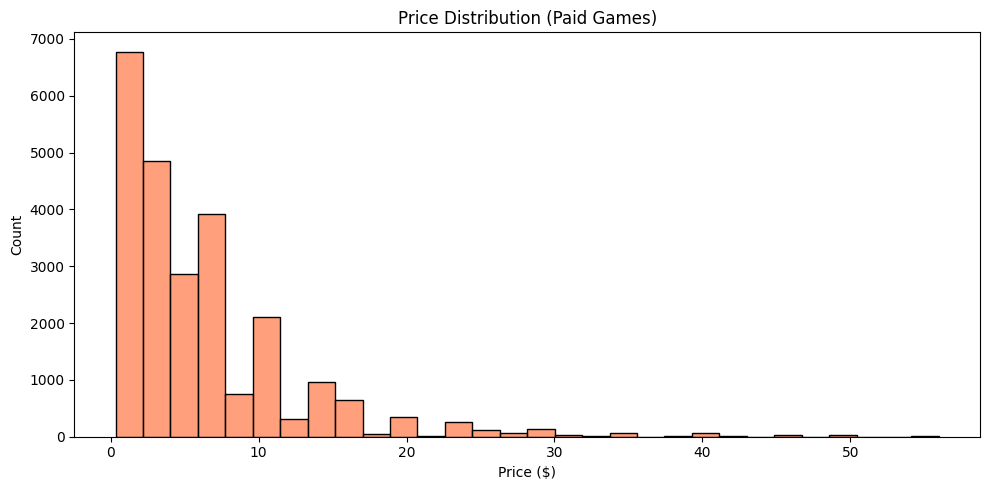

In [18]:
#prices distribution
paid_games = df[df['price'] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(paid_games[paid_games['price'] <= 60]['price'], bins=30, color='coral')
plt.title('Price Distribution (Paid Games)')
plt.xlabel('Price ($)')
plt.tight_layout()
plt.show()

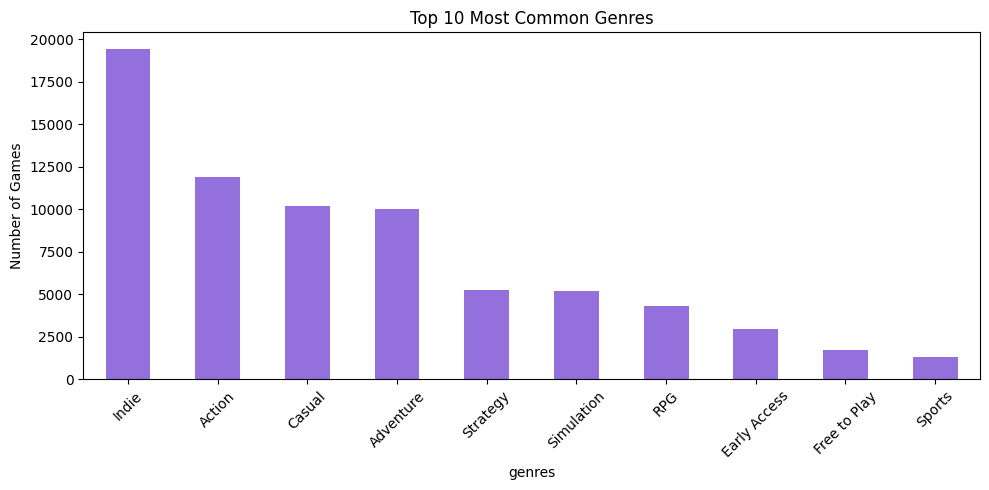

In [19]:
#tob genres by count
df_genres = df.copy()
df_genres['genres'] = df_genres['genres'].str.split(';')
df_genres = df_genres.explode('genres')

genre_count = df_genres['genres'].value_counts().head(10)

plt.figure(figsize=(10, 5))
genre_count.plot(kind='bar', color='mediumpurple')
plt.title('Top 10 Most Common Genres')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

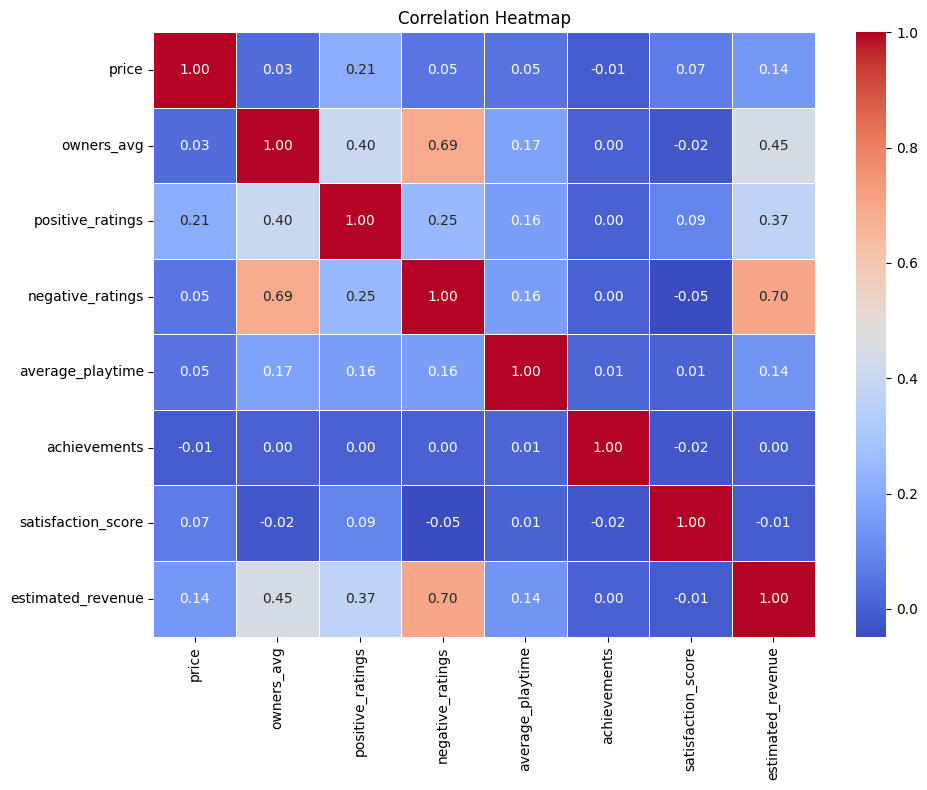

In [21]:
#Correlation Heatmap
# Ensure 'total_ratings' and 'satisfaction_score' are calculated
df['total_ratings']      = df['positive_ratings'] + df['negative_ratings']
# Handle potential division by zero for satisfaction_score if total_ratings is 0
df['satisfaction_score'] = df.apply(lambda row: (row['positive_ratings'] / row['total_ratings']) * 100 if row['total_ratings'] > 0 else 0, axis=1)

# Ensure 'owners_avg' and related columns are calculated
# Clean the 'owners' column
df['owners'] = df['owners'].str.replace(' ', '').str.replace('+', '')
# Split 'owners' into 'min' and 'max'
df[['min', 'max']] = df['owners'].str.split('-', expand=True).astype(float)
# Calculate 'owners_avg'
df['owners_avg'] = (df['min'] + df['max']) / 2

# Ensure 'estimated_revenue' is calculated
df['estimated_revenue'] = df['owners_avg'] * df['price']

num_cols = ['price', 'owners_avg', 'positive_ratings',
            'negative_ratings', 'average_playtime',
            'achievements', 'satisfaction_score', 'estimated_revenue']

plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

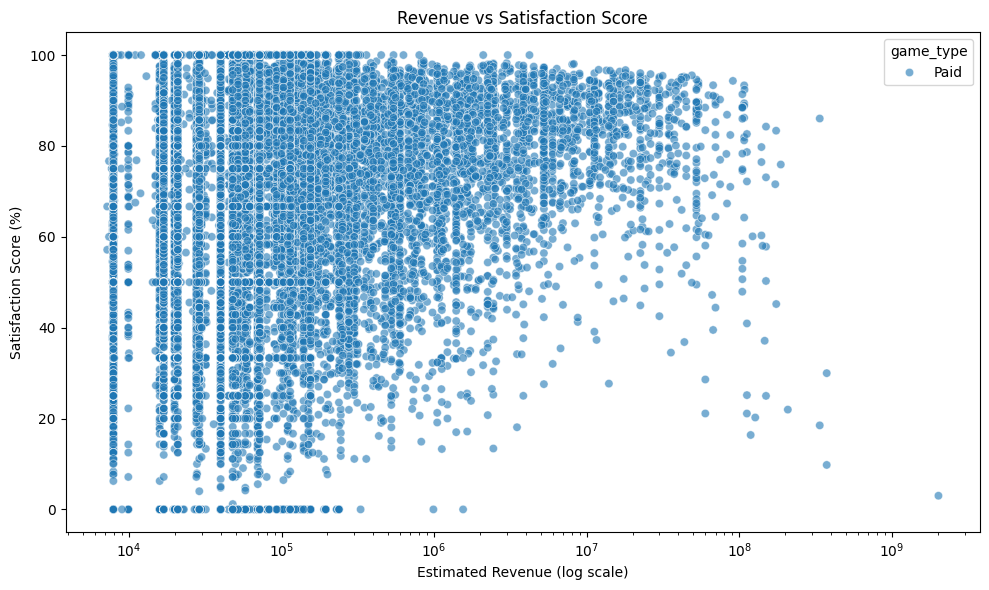

In [22]:
#Revenue vs Satisfaction Scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df[df['estimated_revenue'] > 0],
    x='estimated_revenue',
    y='satisfaction_score',
    hue='game_type',
    alpha=0.6
)
plt.xscale('log')
plt.title('Revenue vs Satisfaction Score')
plt.xlabel('Estimated Revenue (log scale)')
plt.ylabel('Satisfaction Score (%)')
plt.tight_layout()
plt.show()

In [31]:
from google.colab import files
files.download('steam_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>